In [4]:
# I like to keep all my installs in the first block, and my imports in the second
!pip install astropy --upgrade
!pip install photutils
!pip install plotly

     |████████████████████████████████| 9.9 MB 4.4 MB/s eta 0:00:01
     |████████████████████████████████| 359 kB 193.2 MB/s eta 0:00:01


In [47]:
# Imports for handling files
import os
import glob
import re
from pathlib import Path

# The usual suspects for math and plotting
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# FITS handling
from astropy.io import fits

# Some future functions we'll need
from scipy.ndimage import median_filter
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import quad


In [6]:
# GitHub/local file setup
# NGC3526DATA.fits and COMP.fits should be in the same folder as this notebook.
# Download the Google Drive folder of flats/biases and place those FITS files in a local folder named flats_biases.
path = 'flats_biases/'
sn_files = ['NGC3526DATA.fits']

# Open the FITS file
with fits.open(sn_files[0]) as hdu_list:
    print(f"Opened FITS file: {sn_files[0]}")
    print("Number of HDUs:", len(hdu_list))
    print("\n--- HDU Information ---")
    for i, hdu in enumerate(hdu_list):
        print(f"HDU {i}: Type = {type(hdu)}, Name = {hdu.name}, Data Type = {hdu.header.get('XTENSION', 'Primary')}")


Opened FITS file: NGC3526DATA.fits
Number of HDUs: 1

--- HDU Information ---
HDU 0: Type = <class 'astropy.io.fits.hdu.image.PrimaryHDU'>, Name = PRIMARY, Data Type = Primary


In [7]:
# Notice the different trims!

# Open the FITS file
with fits.open(sn_files[0]) as hdu_list:
    # Get the header from the primary HDU (HDU 0)
    primary_header = hdu_list[0].header
    for key, value in primary_header.items():
           print(key,":", value)

SIMPLE : True
BITPIX : 16
NAXIS : 2
NAXIS1 : 2720
NAXIS2 : 161
EXTEND : False
OBJECT : NGC3526
NAMPS : 1
DATE : 2026-03-19T07:29:38
DATE-OBS : 2026-03-19
RA : 11:06:56.6
DEC : +07:10:26
EPOCH : 2000
ROTANGLE : 051
FASTFOC : 1360
AIRMASS : 1.14
RRA : 11:06:56.6
RDEC : +07:10:26
REPOCH : 2000
TRA : 11:06:56.959
TDEC : 07:11:17.79
TEPOCH : 2000.00
ST :  12:13:36.66
HA :  01:06:14.34
DOME :  160.9
UT : 07:29:38
UTEND : 07:49:38
MJD : 61118.31919
GJDN : 2461118.81919
HJDN : 2461118.824773
SITENAME : flwo1
SITELONG : +110:52:39.0
SITELAT : +31:40:51.4
SITEELEV : 2320.0
DETECTOR : FAST3
CCDSERIA : STA520A SN4377
INSTRUME : FAST
OBSERVAT : flwo1
IRAFNAME : 0057.NGC3526.fits
DISKFILE : 57
DISKDIR : /data/fast/2026.0318
TELESCOP : TILLINGHAST
DISPAXIS : 1
EXPTIME : 1200.0
DARKTIME : 1200.0
IMAGETYP : OBJECT
BZERO : 32768.0
BSCALE : 1.0
CCDSUM : 1 2
BIN : 2
LTM1_1 : 1.0
LTM2_2 : 0.5
LTV1 : 32.0
LTV2 : 0.25
DATASEC : [33:2720,1:161]
CCDSEC : [33:2720,1:161]
TRIMSEC : [35:2715,1:161]
BIASSEC : [2:3

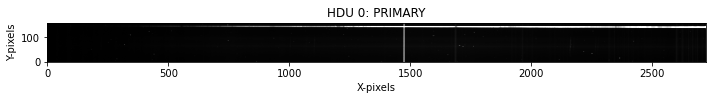

In [8]:
# Open the FITS file
with fits.open(sn_files[0]) as hdu_list:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    hdu = hdu_list[0]
    image_data = hdu.data

    im = ax.imshow(image_data, origin='lower', cmap='gray', vmin=np.percentile(image_data, 1), vmax=np.percentile(image_data, 99))
    ax.set_title(f"HDU {i}: {hdu.name}")
    ax.set_xlabel("X-pixels")
    ax.set_ylabel("Y-pixels")

    plt.tight_layout()
    plt.show()


Found 41 BIAS files for FAST in flats_biases/
Created median bias. Shape: (161, 2680)


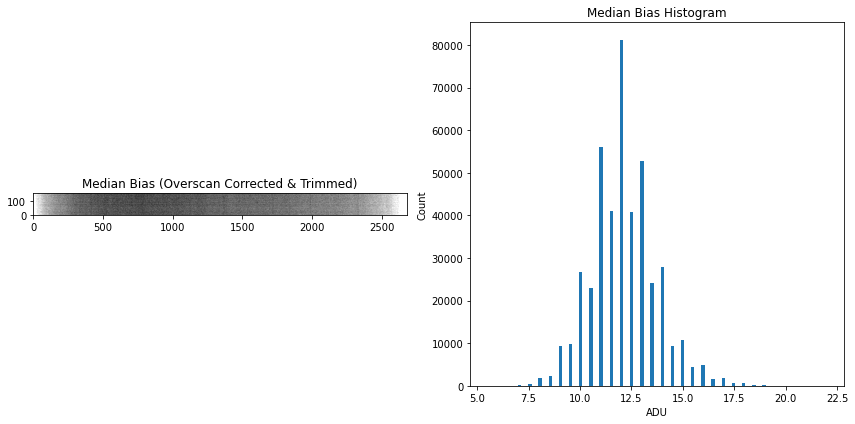

In [12]:
# The 'path' variable is already defined from previous cells.

bias_files = glob.glob(path + '*BIAS*.fits')

bias_stack = []

print(f"Found {len(bias_files)} BIAS files for FAST in {path}")

if not bias_files:
    print("No BIAS files found. Please check the path and file names.")
else:
    # Using header-defined sections:
    # BIASSEC : [2:30,1:161] -> 0-indexed: [1:29]
    # TRIMSEC : [35:2715,1:161] -> 0-indexed: [34:2714]
    oscan_start, oscan_end = 1, 29
    trim_start, trim_end = 34, 2714
    CCD_to_reduce = 0

    for fn in bias_files:
        try:
            data = fits.getdata(fn, CCD_to_reduce)
        except IndexError:
            print(f"Warning: FITS file {os.path.basename(fn)} does not have HDU {CCD_to_reduce}. Skipping.")
            continue

        # --- Overscan subtraction (Left side) ---
        overscan = data[:, oscan_start:oscan_end]
        bias_level = np.median(overscan, axis=1)

        data_corr = data - bias_level[:, None]

        # --- Trim to 'good' part of CCD ---
        data_trim = data_corr[:, trim_start:trim_end]

        bias_stack.append(data_trim)

    if bias_stack:
        bias_stack = np.array(bias_stack)
        med_bias = np.median(bias_stack, axis=0)

        print(f"Created median bias. Shape: {med_bias.shape}")

        plt.figure(figsize=(12,6))

        # --- Median Bias Image ----
        plt.subplot(121)
        plt.imshow(med_bias,
                   vmin=np.percentile(med_bias, 5),
                   vmax=np.percentile(med_bias, 95),
                   cmap='gray', origin='lower')
        plt.title("Median Bias (Overscan Corrected & Trimmed)")

        # --- Histogram ---
        plt.subplot(122)
        plt.hist(med_bias.flatten(), bins=100)
        plt.title("Median Bias Histogram")
        plt.xlabel("ADU")
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()
    else:
        print("No valid data processed.")

--- Found Flat Files ---
Created median flat. Shape: (161, 2680)


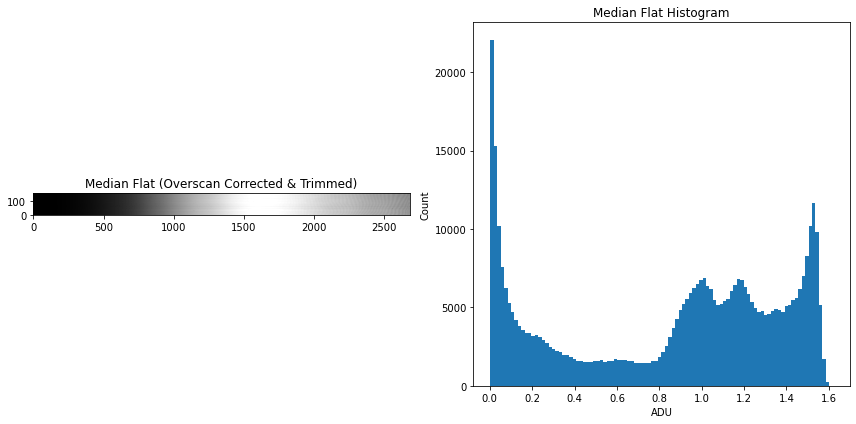

In [13]:
all_flat_files = glob.glob(path + '*FLAT*.fits')
flat_stack = []
print("--- Found Flat Files ---")
if not all_flat_files:
    print("No FLAT files found. Please check the path and file names.")
else:
    for fn in all_flat_files:
        try:
            data = fits.getdata(fn, CCD_to_reduce)
        except IndexError:
            print(f"Warning: FITS file {os.path.basename(fn)} does not have HDU {CCD_to_reduce}. Skipping.")
            continue

        # --- Overscan subtraction (Left side) ---
        overscan = data[:, oscan_start:oscan_end]
        bias_level = np.median(overscan, axis=1)

        data_corr = data - bias_level[:, None]

        # --- Trim to 'good' part of CCD ---
        data_trim = data_corr[:, trim_start:trim_end]

        flat_stack.append(data_trim)

    if flat_stack:
        flat_stack = np.array(flat_stack)
        med_flat = np.median(flat_stack, axis=0)

        med_flat = med_flat / np.median(med_flat) # I have added this line for the flat!

        print(f"Created median flat. Shape: {med_flat.shape}")

        plt.figure(figsize=(12,6))

        # --- Median Flat Image ----
        plt.subplot(121)
        plt.imshow(med_flat,
                   vmin=np.percentile(med_flat, 5),
                   vmax=np.percentile(med_flat, 95),
                   cmap='gray', origin='lower')
        plt.title("Median Flat (Overscan Corrected & Trimmed)")

        # --- Histogram ---
        plt.subplot(122)
        plt.hist(med_flat.flatten(), bins=100)
        plt.title("Median Flat Histogram")
        plt.xlabel("ADU")
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()

flat_files = all_flat_files # Assigning all found flat files as the ones to be processed

Science image reduced: NGC3526DATA.fits
Final shape: (161, 2680)


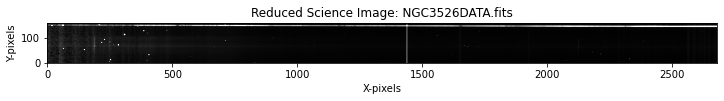

In [14]:
science_file = 'NGC3526DATA.fits'

# Load raw data
science = fits.getdata(science_file, CCD_to_reduce)

# --- Overscan subtraction (Left side) ---
overscan = science[:, oscan_start:oscan_end]
bias_level_science = np.median(overscan, axis=1)
science_corr = science - bias_level_science[:, None]

# --- Trim to 'good' part of CCD ---
science_trim = science_corr[:, trim_start:trim_end]

# --- Bias subtraction ---
science_biascorr = science_trim - med_bias

# --- Flat division ---
science_reduced = science_biascorr / med_flat

print(f"Science image reduced: {os.path.basename(science_file)}")
print(f"Final shape: {science_reduced.shape}")

plt.figure(figsize=(12, 6))
plt.imshow(science_reduced,
           vmin=np.percentile(science_reduced, 1),
           vmax=np.percentile(science_reduced, 99),
           cmap='gray', origin='lower')
plt.title(f"Reduced Science Image: {os.path.basename(science_file)}")
plt.xlabel("X-pixels")
plt.ylabel("Y-pixels")
plt.show()


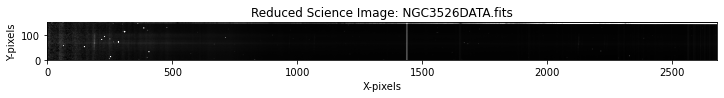

In [15]:
science_reduced_cropped = science_reduced[:150, :]
plt.figure(figsize=(12, 6))
plt.imshow(science_reduced_cropped,
           vmin=np.percentile(science_reduced_cropped, 1),
           vmax=np.percentile(science_reduced_cropped, 99),
           cmap='gray', origin='lower')
plt.title(f"Reduced Science Image: {os.path.basename(science_file)}")
plt.xlabel("X-pixels")
plt.ylabel("Y-pixels")
plt.show()

Here, we will extract the "trace" of the spectrum. That is, we will isolate the object from the 2D spectrum.

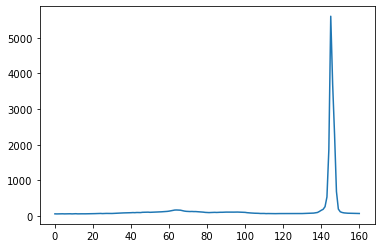

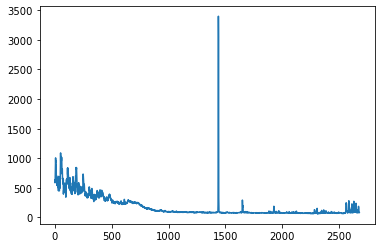

In [16]:
spatial_profile = np.nanmedian(science_reduced, axis=1)
plt.plot(spatial_profile)
plt.show()
spatial_profile = np.nanmedian(science_reduced, axis=0)
plt.plot(spatial_profile)

Detected peak of the trace at Y-pixel: 64


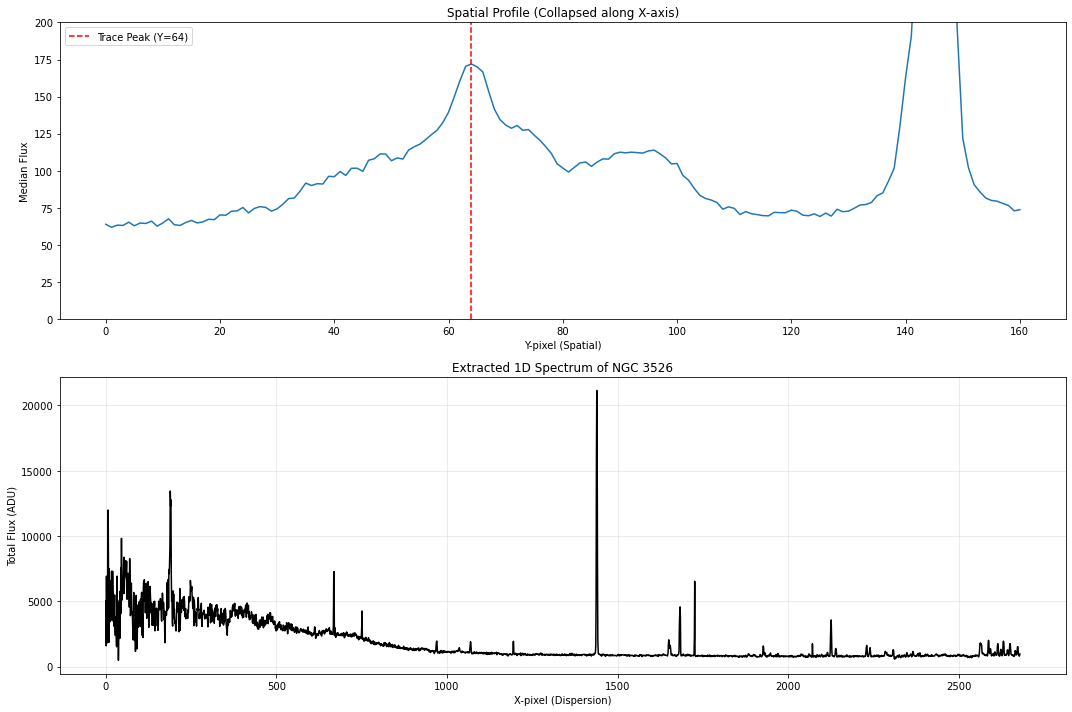

In [17]:
# --- Plotting ---
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)


# 1. Find the trace (spatial profile)
# We sum along the dispersion axis (columns) to find the peak in Y
spatial_profile = np.nanmedian(science_reduced, axis=1)
y_peak = 64

# Subplot 1: Spatial Profile to show the trace identification
plt.plot(spatial_profile)
plt.axvline(y_peak, color='red', linestyle='--', label=f'Trace Peak (Y={y_peak})')
plt.title("Spatial Profile (Collapsed along X-axis)")
plt.xlabel("Y-pixel (Spatial)")
plt.ylabel("Median Flux")
plt.ylim(0, 200)
plt.legend()

print(f"Detected peak of the trace at Y-pixel: {y_peak}")

# 2. Extract the 1D spectrum
# Define an aperture width (e.g., +/- 3 pixels around the peak)
aperture_half_width = 3
extraction_range = slice(y_peak - aperture_half_width, y_peak + aperture_half_width)
spectrum_1d = np.nansum(science_reduced[extraction_range, :], axis=0)

# Subplot 2: The extracted 1D spectrum
plt.subplot(2, 1, 2)
plt.plot(spectrum_1d, color='black')
plt.title("Extracted 1D Spectrum of NGC 3526")
plt.xlabel("X-pixel (Dispersion)")
plt.ylabel("Total Flux (ADU)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

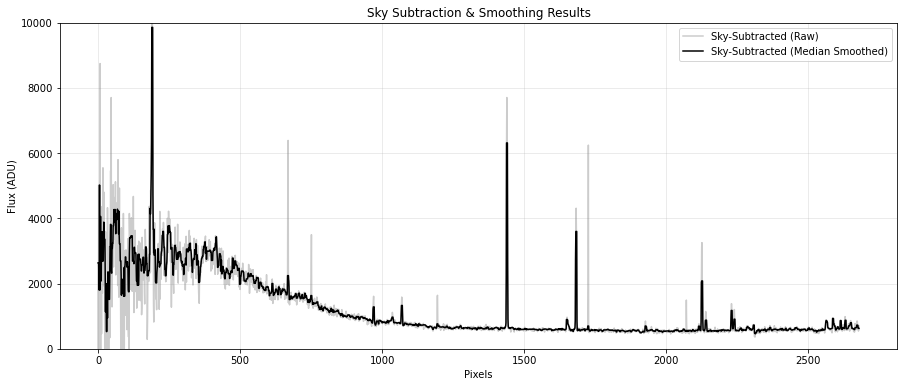

In [18]:
# 1. Define sky regions (rows away from the target trace at Y=64)
sky_regions = np.concatenate([science_reduced[20:50, :], science_reduced[110:140, :]], axis=0)

# 2. Create the master sky spectrum
sky_spectrum_1d = np.nanmedian(sky_regions, axis=0)

# 3. Scale the sky to the aperture width
aperture_factor = 4
sky_scaled = sky_spectrum_1d * aperture_factor

# 4. Subtract sky from the target spectrum
spectrum_1d_skysub = spectrum_1d - sky_scaled

# 5. Apply a small median filter for smoothing (window of 3 pixels)
spectrum_smoothed = median_filter(spectrum_1d_skysub, size=6)

# --- Visualization ---
plt.figure(figsize=(15, 6))
plt.plot(spectrum_1d_skysub, color='gray', alpha=0.4, label='Sky-Subtracted (Raw)')
plt.plot(spectrum_smoothed, color='black', label='Sky-Subtracted (Median Smoothed)')

plt.title("Sky Subtraction & Smoothing Results")
plt.xlabel("Pixels")
plt.ylabel("Flux (ADU)")
plt.ylim([0,10000])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Processing arc: COMP.fits


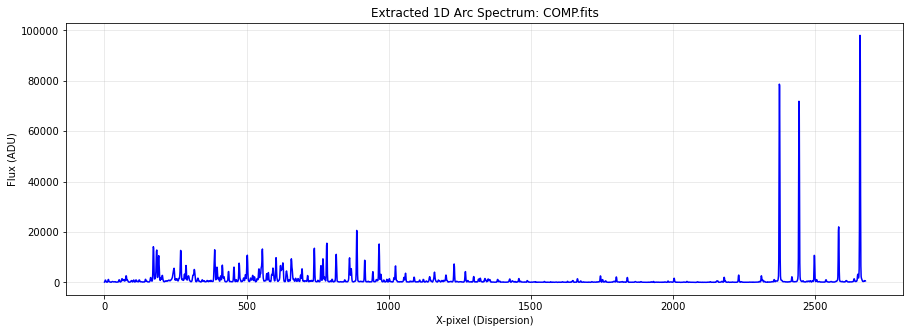

In [19]:
#Convert pixels to wavelength using closest arclamp
arc_file = 'COMP.fits'

print(f"Processing arc: {os.path.basename(arc_file)}")

# 1. Load data
arc_data = fits.getdata(arc_file, CCD_to_reduce)

# 2. Basic Reduction (No Flat Field for Arcs)
# Overscan
arc_overscan = arc_data[:, oscan_start:oscan_end]
arc_bias_level = np.median(arc_overscan, axis=1)
arc_corr = arc_data - arc_bias_level[:, None]

# Trim and Bias Subtract using header-defined regions
arc_trim = arc_corr[:, trim_start:trim_end]
arc_reduced = arc_trim - med_bias

# 3. Extract 1D Arc Spectrum using the SAME trace as the science image
# extraction_range was defined in the science extraction cell
arc_spectrum_1d = np.nansum(arc_reduced[extraction_range, :], axis=0)

# Plot it
plt.figure(figsize=(15, 5))
plt.plot(arc_spectrum_1d, color='blue')
plt.title(f"Extracted 1D Arc Spectrum: {os.path.basename(arc_file)}")
plt.xlabel("X-pixel (Dispersion)")
plt.ylabel("Flux (ADU)")
plt.grid(True, alpha=0.3)
plt.show()


Found 48 emission lines in the arc.


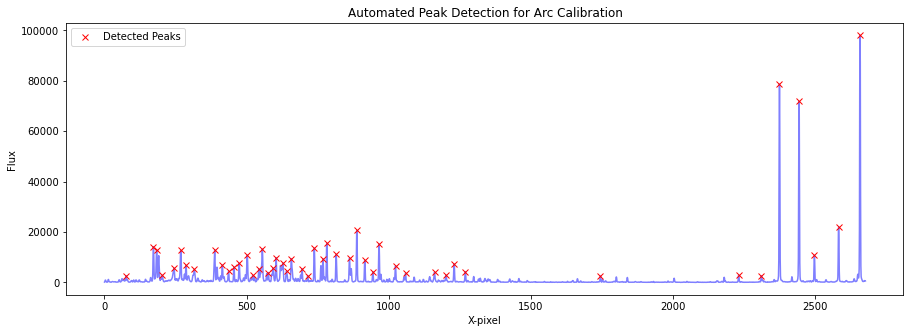

In [20]:
# 1. Automatically find peaks in the arc spectrum
# Reducing distance and height to ensure we catch the fainter edge lines
peaks, properties = find_peaks(arc_spectrum_1d, height=np.percentile(arc_spectrum_1d, 90), distance=10)

# Extract the X-pixel positions of the peaks
detected_pixels = peaks
print(f"Found {len(detected_pixels)} emission lines in the arc.")

plt.figure(figsize=(15, 5))
plt.plot(arc_spectrum_1d, color='blue', alpha=0.5)
plt.plot(detected_pixels, arc_spectrum_1d[detected_pixels], "x", color='red', label='Detected Peaks')
plt.title("Automated Peak Detection for Arc Calibration")
plt.xlabel("X-pixel")
plt.ylabel("Flux")

plt.legend()
plt.show()

Text(0, 0.5, 'Wavelength Value')

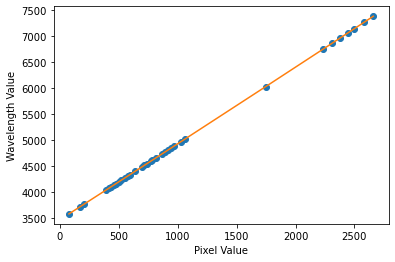

In [21]:
# 1. This is a solution from the Ar lamp
Ar_lamp = """
	         69.83 3575.40181  3577.6364   4.0 1 1 ArII
	        173.81 3724.56556  3719.2638   4.0 1 1 ArII
	        200.30 3762.70113  3767.1883   4.0 1 1 ArII
	        389.14 4036.03156  4034.9488   4.0 1 1 ArII
	        397.75 4048.55337   4045.561   4.0 1 1 ArII
	        416.37 4075.63949  4073.1541   4.0 1 1 ArI
	        438.19 4107.41827    4105.07   4.0 1 1 ArII
	        457.35 4135.33392  4132.8886   4.0 1 1 ArII
	        475.71 4162.10809   4159.762   4.0 1 1 ArII
	        497.89 4194.48163   4201.858   4.0 1 1 ArI
	        523.36 4231.67628  4238.4126   4.0 1 1 ArI
	        557.22 4281.17982  4278.7316   4.0 1 1 ArII
	        572.78 4303.95145  4301.8591   4.0 1 1 ArI
	        590.92 4330.50502   4334.779   4.0 1 1 ArII
	        642.35 4405.88237  4402.2222   4.0 1 1 ArII
	        692.30  4479.2032  4483.0679   4.0 1 1 ArI
	        710.87 4506.48197   4511.998   4.0 1 1 ArII
	        740.21 4549.61034  4546.3258   4.0 1 1 ArII
	        763.62 4584.04803  4580.6326   4.0 1 1 ArII
	        770.81 4594.62313  4591.1837   4.0 1 1 ArII
	        776.48 4602.96328  4610.8582   4.0 1 1 ArI
	        817.14 4662.82399   4659.205   4.0 1 1 ArII
	        864.14 4732.08769  4737.2302   4.0 1 1 ArII
	        889.98 4770.18611  4766.1968   4.0 1 1 ArII
	        917.99 4811.49062  4807.3635   4.0 1 1 ArI
	        946.37 4853.37534  4849.1639   4.0 1 1 ArII
	        968.19 4885.57568  4881.2263   4.0 1 1 ArII
	       1020.98 4963.51916  4966.4649   4.0 1 1 ArII
	       1056.26 5015.62824  5018.5619   4.0 1 1 ArII
	       1084.34 5057.12633  5063.4483   4.0 1 1 ArII
	       1747.80 6036.35344   6033.797   4.0 1 1 ArII
	       1842.34 6175.70772  6173.9855   4.0 1 1 ArII
	       2183.31 6678.67084   6679.126   4.0 1 1 ArII
	       2234.43 6754.18301   6754.698   4.0 1 1 ArII
	       2314.47 6872.49738   6873.185   4.0 1 1 ArII
	       2378.10  6966.6166   6967.352   4.0 1 1 ArI
	       2421.98 7031.56808    7032.19   4.0 1 1 ArII
	       2447.01 7068.64731   7069.167   4.0 1 1 ArII
	       2501.04 7148.70742   7148.012   4.0 1 1 ArII
	       2586.37 7275.29815    7274.94   4.0 1 1 ArI
	       2661.77 7387.30618   7386.014   4.0 1 1 ArI
"""

# Extract reference wavelengths from the user template
ref_lambdas = []
initial_pixels = []
initial_wavelengths = []
for line in Ar_lamp.strip().split('\n'):
    parts = line.strip().split()
    if len(parts) >= 3:
        initial_pixels.append(float(parts[0]))
        initial_wavelengths.append(float(parts[1]))
        ref_lambdas.append(float(parts[2]))

initial_pixels = np.array(initial_pixels)
initial_wavelengths = np.array(initial_wavelengths)
ref_lambdas = np.unique(ref_lambdas)
ref_lambdas_sorted = np.sort(ref_lambdas)

# Initial Model (Order 2)
initial_poly_coeffs = np.polyfit(initial_pixels, initial_wavelengths, 2)
initial_wavelength_model = np.poly1d(initial_poly_coeffs)

# Match detected peaks to the new Argon reference lines -- initial guess
detected_waves = initial_wavelength_model(detected_pixels)

matched_pixels = []
matched_wavelengths = []
tolerance = 15.0 # angstrom

for i, p in enumerate(detected_pixels):
	# First, calculate the DIFFERENCE between my detected pixel and the references -- so I can find the closest!
	differences = np.abs(ref_lambdas_sorted - detected_waves[i])
	best_match = np.argmin(differences)
	if differences[best_match] < tolerance:
		matched_pixels.append(p)
		matched_wavelengths.append(ref_lambdas_sorted[best_match])


# Refine Solution (Order 2)
coefficients_of_new_solution = np.polyfit(matched_pixels, matched_wavelengths, 2)
final_wavelength_model = np.poly1d(coefficients_of_new_solution)


# We want to return:
wavelengths = final_wavelength_model(np.arange(len(spectrum_1d)))

# Plot to see how well we're doing....
plt.plot(matched_pixels, matched_wavelengths,'o')
plt.plot(matched_pixels, final_wavelength_model(matched_pixels))
plt.xlabel('Pixel Value')
plt.ylabel('Wavelength Value')

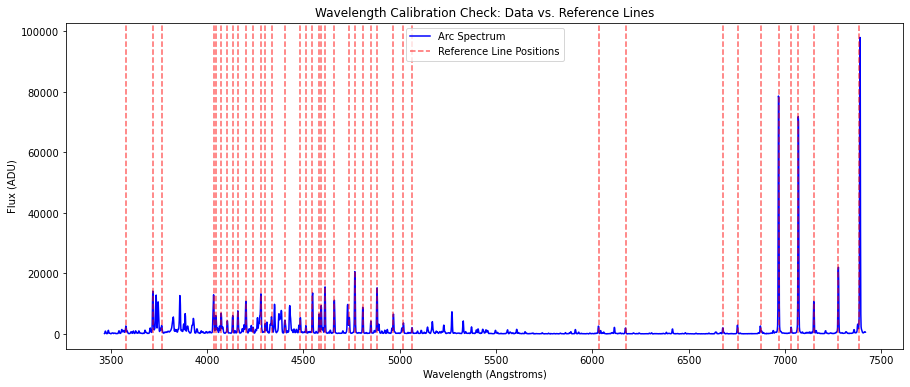

In [22]:
plt.figure(figsize=(15, 6))
plt.plot(wavelengths, arc_spectrum_1d, color='blue', label='Calibrated Arc')

# Plot reference lines as vertical dashed lines
for wave in ref_lambdas:
    plt.axvline(wave, color='red', linestyle='--', alpha=0.6)
    if wave == 7514.7: # Specifically label the right-most anchor for confirmation
        plt.text(wave, np.max(arc_spectrum_1d), f'{wave}A', rotation=90, verticalalignment='top', color='red')

plt.title("Wavelength Calibration Check: Data vs. Reference Lines")
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux (ADU)")
plt.legend(['Arc Spectrum', 'Reference Line Positions'])
plt.show()

In [24]:
# Redshift provided by user
z = 0.0047 #NGC 3526

# Rest wavelengths of the Balmer series (Angstroms)
balmer_rest = {
    '[N II] 6548': 6548.1,
    'H-alpha 6563': 6562.8,
    '[N II] 6584': 6583.5,
    '[S II] 6716': 6716.4,
    '[S II] 6731': 6730.8
}

# Create an interactive plot of the calibrated spectrum
fig_cal = go.Figure()

# Add the spectrum
fig_cal.add_trace(go.Scatter(
    x=wavelengths,
    y=spectrum_smoothed,
    mode='lines',
    line=dict(color='black', width=1.5),
    name='Calibrated Spectrum'
))

# Add vertical lines for redshifted Balmer series
for name, rest_wave in balmer_rest.items():
    obs_wave = rest_wave * (1 + z)

    fig_cal.add_vline(
        x=obs_wave,
        line_dash="dash",
        line_color="red",
        annotation_text=name,
        annotation_position="top"
    )

fig_cal.update_layout(
    title=f'Interactive Wavelength Calibrated Spectrum (z={z} Balmer Overlays)',
    xaxis_title='Wavelength (Ångströms)',
    yaxis_title='Flux (ADU)',
    template='plotly_white',
    hovermode='x',
    xaxis=dict(range=[wavelengths[0], wavelengths[-1]])
)

fig_cal.show()

Expected H-alpha wavelength from z = 0.0047: 6593.65 Å
Number of points in H-alpha window: 34
Simple peak estimate of observed H-alpha wavelength: 6592.69 Å
Gaussian-fit observed wavelength: 6594.21 ± 0.24 Å
Systemic velocity from fitted H-alpha: 1435.0 km/s


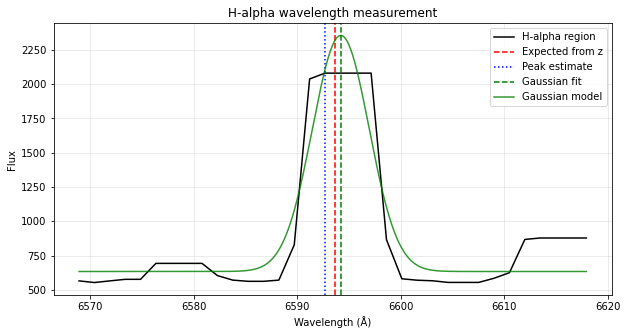

In [25]:
# H-alpha rest wavelength (Angstrom)
lambda_rest = 6562.8

# Speed of light (km/s)
c_kms = 299792.458

# Expected observed wavelength from the redshift guess
lambda_expected = lambda_rest * (1 + z)

print(f"Expected H-alpha wavelength from z = {z}: {lambda_expected:.2f} Å")

# -----------------------------------
# Step 1: isolate a small region around H-alpha
# -----------------------------------
window = 25  # Angstroms on either side
mask = (wavelengths > lambda_expected - window) & (wavelengths < lambda_expected + window)

wave_Ha = wavelengths[mask]
flux_Ha = spectrum_smoothed[mask]

# Check that something was selected
print(f"Number of points in H-alpha window: {len(wave_Ha)}")

# -----------------------------------
# Step 2: quick estimate = highest point
# -----------------------------------
peak_idx = np.argmax(flux_Ha)
lambda_peak = wave_Ha[peak_idx]

print(f"Simple peak estimate of observed H-alpha wavelength: {lambda_peak:.2f} Å")

# -----------------------------------
# Step 3: better estimate = Gaussian fit
# -----------------------------------
def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

A0 = np.max(flux_Ha) - np.median(flux_Ha)
mu0 = lambda_peak
sigma0 = 2.0
C0 = np.median(flux_Ha)

p0 = [A0, mu0, sigma0, C0]

try:
    popt, pcov = curve_fit(gaussian, wave_Ha, flux_Ha, p0=p0, maxfev=10000)
    A_fit, lambda_obs, sigma_fit, C_fit = popt
    lambda_obs_err = np.sqrt(np.diag(pcov))[1]

    print(f"Gaussian-fit observed wavelength: {lambda_obs:.2f} ± {lambda_obs_err:.2f} Å")

    # -----------------------------------
    # Step 4: convert wavelength to velocity
    # -----------------------------------
    velocity_kms = c_kms * (lambda_obs - lambda_rest) / lambda_rest
    print(f"Systemic velocity from fitted H-alpha: {velocity_kms:.1f} km/s")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(wave_Ha, flux_Ha, color='black', label='H-alpha region')
    plt.axvline(lambda_expected, color='red', linestyle='--', label='Expected from z')
    plt.axvline(lambda_peak, color='blue', linestyle=':', label='Peak estimate')
    plt.axvline(lambda_obs, color='green', linestyle='--', label='Gaussian fit')

    xfine = np.linspace(wave_Ha.min(), wave_Ha.max(), 500)
    plt.plot(xfine, gaussian(xfine, *popt), color='green', alpha=0.8, label='Gaussian model')

    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")
    plt.title("H-alpha wavelength measurement")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

except Exception as e:
    print("Gaussian fit failed.")
    print("Error:", e)

    # fallback velocity from raw peak
    velocity_kms = c_kms * (lambda_peak - lambda_rest) / lambda_rest
    print(f"Fallback velocity from peak wavelength: {velocity_kms:.1f} km/s")

    plt.figure(figsize=(10, 5))
    plt.plot(wave_Ha, flux_Ha, color='black')
    plt.axvline(lambda_expected, color='red', linestyle='--', label='Expected from z')
    plt.axvline(lambda_peak, color='blue', linestyle='--', label='Peak estimate')
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")
    plt.title("H-alpha region (fit failed, showing peak estimate)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [26]:
# --- Next step: measure H-alpha wavelength and velocity row-by-row along the slit ---

row_list = []
lambda_list = []
velocity_list = []
lambda_err_list = []
velocity_err_list = [] # Initialize list for velocity errors

# how many rows to combine per measurement
bin_half_width = 1   # 1 = 3-row bins; increase to 2 if too noisy

# use the same H-alpha window as before
window = 25
mask = (wavelengths > lambda_expected - window) & (wavelengths < lambda_expected + window)
wave_Ha = wavelengths[mask]

for y0 in range(bin_half_width, science_reduced.shape[0] - bin_half_width):

    # extract a small spatial bin around this row
    rows = slice(y0 - bin_half_width, y0 + bin_half_width + 1)
    nrows = 2 * bin_half_width + 1

    # object spectrum from this bin
    spec_1d = np.nansum(science_reduced[rows, :], axis=0)

    # subtract sky scaled to same number of rows
    spec_skysub = spec_1d - sky_spectrum_1d * nrows

    # isolate H-alpha region
    flux_Ha = spec_skysub[mask]

    # skip empty / bad regions
    if len(flux_Ha) < 5 or np.all(~np.isfinite(flux_Ha)):
        continue
    if np.nanmax(flux_Ha) <= np.nanmedian(flux_Ha):
        continue

    # initial guess from the peak
    peak_idx = np.nanargmax(flux_Ha)
    mu0 = wave_Ha[peak_idx]
    A0 = np.nanmax(flux_Ha) - np.nanmedian(flux_Ha)
    sigma0 = 2.0
    C0 = np.nanmedian(flux_Ha)

    try:
        popt, pcov = curve_fit(
            gaussian,
            wave_Ha,
            flux_Ha,
            p0=[A0, mu0, sigma0, C0],
            maxfev=10000
        )

        lambda_obs = popt[1]
        lambda_err = np.sqrt(np.diag(pcov))[1]
        velocity_kms = c_kms * (lambda_obs - lambda_rest) / lambda_rest
        velocity_err = (c_kms / lambda_rest) * lambda_err # Calculate velocity error

        row_list.append(y0)
        lambda_list.append(lambda_obs)
        lambda_err_list.append(lambda_err)
        velocity_list.append(velocity_kms)
        velocity_err_list.append(velocity_err) # Append velocity error

    except:
        continue

# convert to arrays
row_vals = np.array(row_list)
lambda_vals = np.array(lambda_list)
lambda_err_vals = np.array(lambda_err_list)
velocity_vals = np.array(velocity_list)
velocity_err_vals = np.array(velocity_err_list) # Convert to array

print(f"Measured H-alpha successfully in {len(row_vals)} spatial bins. Some rows have very large error, which is normal for noisy data; it indicates that the Gaussian fit was unreliable for that particular row. These unreliable points will be addressed in later steps.")

# quick look at the first few points
for i in range(min(10, len(row_vals))):
    print(f"row={row_vals[i]:3d},  lambda_obs={lambda_vals[i]:8.2f} \u00c5,  v={velocity_vals[i]:8.1f} km/s, v_err={velocity_err_vals[i]:8.1f} km/s")

Measured H-alpha successfully in 159 spatial bins. Some rows have very large error, which is normal for noisy data; it indicates that the Gaussian fit was unreliable for that particular row. These unreliable points will be addressed in later steps.
row=  1,  lambda_obs= 6575.28 Å,  v=   570.2 km/s, v_err=   152.9 km/s
row=  2,  lambda_obs= 6600.73 Å,  v=  1732.8 km/s, v_err= 22520.2 km/s
row=  3,  lambda_obs= 6574.91 Å,  v=   553.2 km/s, v_err=    60.3 km/s
row=  4,  lambda_obs= 6574.07 Å,  v=   514.9 km/s, v_err=1588225.7 km/s
row=  5,  lambda_obs= 6610.14 Å,  v=  2162.4 km/s, v_err=   304.3 km/s
row=  6,  lambda_obs= 6581.49 Å,  v=   853.8 km/s, v_err= 66594.0 km/s
row=  7,  lambda_obs= 6605.18 Å,  v=  1936.0 km/s, v_err=    23.1 km/s
row=  8,  lambda_obs= 6585.98 Å,  v=  1059.1 km/s, v_err= 15602.3 km/s
row=  9,  lambda_obs= 6665.47 Å,  v=  4689.9 km/s, v_err=576013.6 km/s
row= 10,  lambda_obs= 6618.36 Å,  v=  2538.0 km/s, v_err=  1051.2 km/s


<ipython-input-26-9a6473a348a8>:55: RuntimeWarning: invalid value encountered in sqrt
  lambda_err = np.sqrt(np.diag(pcov))[1]
/Applications/anaconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


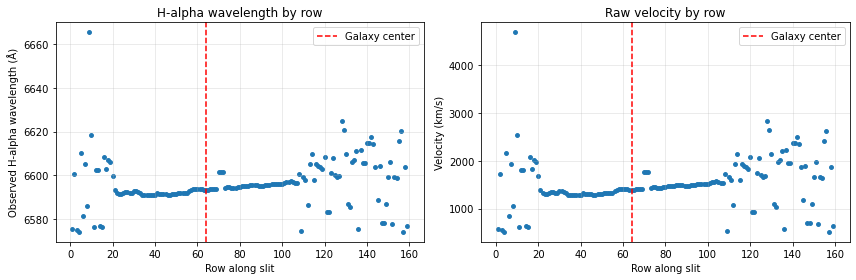

In [27]:
# --- Inspect the raw wavelength and velocity points ---

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(row_vals, lambda_vals, s=15)
plt.axvline(y_peak, color='red', linestyle='--', label='Galaxy center')
plt.xlabel("Row along slit")
plt.ylabel("Observed H-alpha wavelength (Å)")
plt.title("H-alpha wavelength by row")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(row_vals, velocity_vals, s=15)
plt.axvline(y_peak, color='red', linestyle='--', label='Galaxy center')
plt.xlabel("Row along slit")
plt.ylabel("Velocity (km/s)")
plt.title("Raw velocity by row")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# --- Convert absolute velocities into velocities relative to galaxy center ---

# choose the measured wavelength closest to the spatial center as systemic
center_idx = np.argmin(np.abs(row_vals - y_peak))
lambda_sys = lambda_vals[center_idx]

print(f"Center row used: {row_vals[center_idx]}")
print(f"Systemic wavelength: {lambda_sys:.2f} Å")

# velocity relative to the galaxy center
v_rel = c_kms * (lambda_vals - lambda_sys) / lambda_sys

#ERRORS
center_idx = np.argmin(np.abs(row_vals - y_peak))
lambda_sys = lambda_vals[center_idx]
lambda_sys_err = lambda_err_vals[center_idx]

v_rel = c_kms * (lambda_vals - lambda_sys) / lambda_sys

v_rel_err = c_kms * np.sqrt(
    (lambda_err_vals / lambda_sys)**2 +
    ((lambda_vals * lambda_sys_err) / lambda_sys**2)**2
)

# inspect a few values
for i in range(min(10, len(row_vals))):
    print(f"row={row_vals[i]:3d}, lambda_obs={lambda_vals[i]:8.2f} Å, v_rel={v_rel[i]:8.1f} km/s")

Center row used: 64
Systemic wavelength: 6593.40 Å
row=  1, lambda_obs= 6575.28 Å, v_rel=  -823.8 km/s
row=  2, lambda_obs= 6600.73 Å, v_rel=   333.4 km/s
row=  3, lambda_obs= 6574.91 Å, v_rel=  -840.7 km/s
row=  4, lambda_obs= 6574.07 Å, v_rel=  -878.8 km/s
row=  5, lambda_obs= 6610.14 Å, v_rel=   761.1 km/s
row=  6, lambda_obs= 6581.49 Å, v_rel=  -541.4 km/s
row=  7, lambda_obs= 6605.18 Å, v_rel=   535.7 km/s
row=  8, lambda_obs= 6585.98 Å, v_rel=  -337.2 km/s
row=  9, lambda_obs= 6665.47 Å, v_rel=  3276.8 km/s
row= 10, lambda_obs= 6618.36 Å, v_rel=  1134.9 km/s


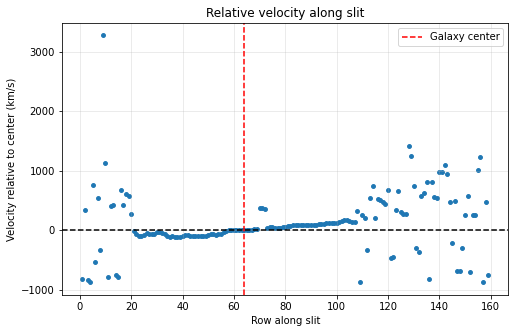

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(row_vals, v_rel, s=15)
plt.axhline(0, color='k', linestyle='--')
plt.axvline(y_peak, color='red', linestyle='--', label='Galaxy center')
plt.xlabel("Row along slit")
plt.ylabel("Velocity relative to center (km/s)")
plt.title("Relative velocity along slit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [30]:
# --- Convert slit row number into projected radius (kpc) ---

D_Mpc = 27 #approximate cited from NED
pixscale = 0.6 #approximate cited from Fabricant et al

arcsec_to_kpc = 0.004848 * D_Mpc
radius_kpc = (row_vals - y_peak) * pixscale * arcsec_to_kpc
radius_abs_kpc = np.abs(radius_kpc)

print("First few radius–velocity pairs:\n")

for i in range(min(10, len(radius_kpc))):
    print(f"R = {radius_kpc[i]:6.2f} kpc,  v = {v_rel[i]:7.1f} km/s")

First few radius–velocity pairs:

R =  -4.95 kpc,  v =  -823.8 km/s
R =  -4.87 kpc,  v =   333.4 km/s
R =  -4.79 kpc,  v =  -840.7 km/s
R =  -4.71 kpc,  v =  -878.8 km/s
R =  -4.63 kpc,  v =   761.1 km/s
R =  -4.56 kpc,  v =  -541.4 km/s
R =  -4.48 kpc,  v =   535.7 km/s
R =  -4.40 kpc,  v =  -337.2 km/s
R =  -4.32 kpc,  v =  3276.8 km/s
R =  -4.24 kpc,  v =  1134.9 km/s


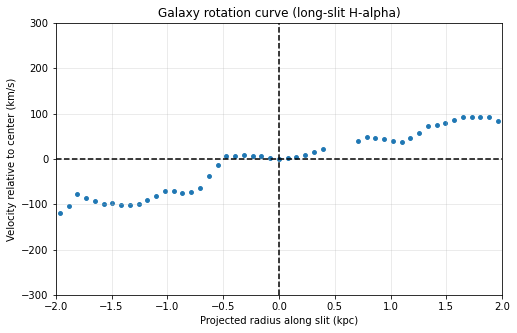

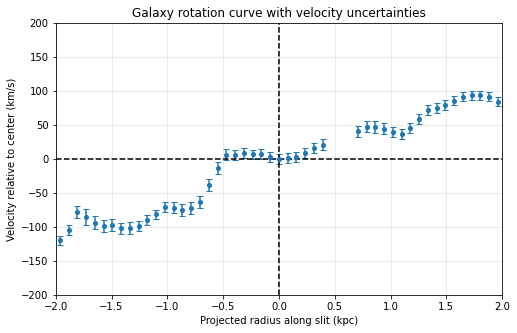

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(radius_kpc, v_rel, s=15)
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Projected radius along slit (kpc)")
plt.ylabel("Velocity relative to center (km/s)")
plt.title("Galaxy rotation curve (long-slit H-alpha)")
plt.grid(alpha=0.3)
plt.xlim(-2, 2)
plt.ylim(-300, 300)
plt.show()

#error bars:

good = np.isfinite(v_rel_err) & (v_rel_err < 50)

plt.figure(figsize=(8,5))
plt.errorbar(
    radius_kpc[good],
    v_rel[good],
    yerr=v_rel_err[good],
    fmt='o',
    markersize=4,
    capsize=3
)

plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Projected radius along slit (kpc)")
plt.ylabel("Velocity relative to center (km/s)")
plt.title("Galaxy rotation curve with velocity uncertainties")
plt.grid(alpha=0.3)
plt.xlim(-2, 2)
plt.ylim(-200, 200)
plt.show()

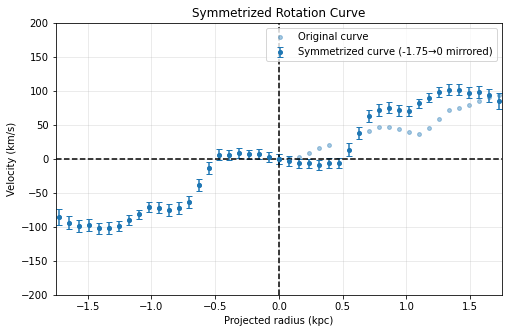

In [32]:
# --- Mirror the rotation curve from LHS to RHS (LHS less noisy, more reliable if we assume symmetry)---

# choose region to mirror
Rmin = -1.75
Rmax = 0

mask_left = (radius_kpc >= Rmin) & (radius_kpc <= Rmax)

R_left = radius_kpc[mask_left]
v_left = v_rel[mask_left]
v_left_err = v_rel_err[mask_left]

# reflect across both axes
R_reflected = -R_left
v_reflected = -v_left
v_reflected_err = v_left_err.copy()

# combine original + mirrored data
R_combined = np.concatenate([R_left, R_reflected])
v_combined = np.concatenate([v_left, v_reflected])
v_combined_err = np.concatenate([v_left_err, v_reflected_err])

# sort for plotting
order = np.argsort(R_combined)
R_combined = R_combined[order]
v_combined = v_combined[order]
v_combined_err = v_combined_err[order]

# plot comparison
plt.figure(figsize=(8,5))

plt.scatter(radius_kpc, v_rel, s=15, alpha=0.4, label="Original curve")
plt.errorbar(
    R_combined,
    v_combined,
    yerr=v_combined_err, # Added uncertainty here
    fmt='o',
    markersize=4,
    capsize=3,
    label=f"Symmetrized curve ({Rmin}→0 mirrored)"
)

plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

plt.xlabel("Projected radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Symmetrized Rotation Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(Rmin, -Rmin)
plt.ylim(-200, 200)

plt.show()

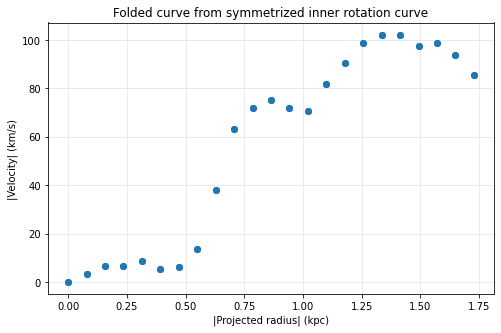

In [33]:

# --- Folded curve from the symmetrized (-2 to 0 kpc mirrored) rotation curve ---

# assumes these already exist from the previous block:
# R_combined
# v_combined

R_fold = np.abs(R_combined)
v_fold = np.abs(v_combined)

# sort by radius
order = np.argsort(R_fold)
R_fold = R_fold[order]
v_fold = v_fold[order]

plt.figure(figsize=(8,5))
plt.plot(R_fold, v_fold, 'o')
plt.xlabel("|Projected radius| (kpc)")
plt.ylabel("|Velocity| (km/s)")
plt.title("Folded curve from symmetrized inner rotation curve")
plt.grid(alpha=0.3)
plt.show()

# Average velocities at identical radii
R_unique = np.unique(R_fold)

v_fold_avg = np.array([
    np.mean(v_fold[R_fold == r])
    for r in R_unique
])

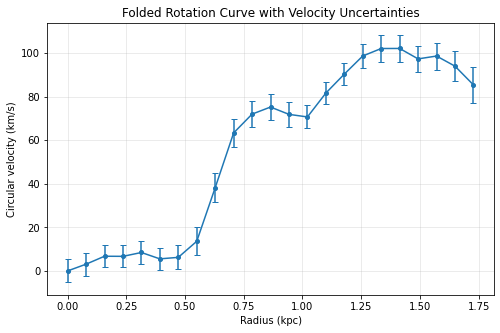

In [34]:
# --- Folded rotation curve with uncertainties ---

# Fold radius and velocity to positive values
R_fold = np.abs(R_combined)
v_fold = np.abs(v_combined)
v_fold_err = v_combined_err.copy()   # errors stay positive

# Sort by radius
order = np.argsort(R_fold)
R_fold = R_fold[order]
v_fold = v_fold[order]
v_fold_err = v_fold_err[order]

# Average duplicate radii using inverse-variance weighting
R_obs = np.unique(R_fold)

v_obs = np.array([
    np.average(
        v_fold[R_fold == r],
        weights=1 / v_fold_err[R_fold == r]**2
    )
    for r in R_obs
])

v_obs_err = np.array([
    np.sqrt(1 / np.sum(1 / v_fold_err[R_fold == r]**2))
    for r in R_obs
])

# Plot folded rotation curve with uncertainties
plt.figure(figsize=(8,5))

plt.errorbar(
    R_obs,
    v_obs,
    yerr=v_obs_err,
    fmt='o-',
    markersize=4,
    capsize=3
)

plt.xlabel("Radius (kpc)")
plt.ylabel("Circular velocity (km/s)")
plt.title("Folded Rotation Curve with Velocity Uncertainties")
plt.grid(alpha=0.3)

plt.show()

Weighted Keplerian mass = 1.226e+08 ± 8.403e+06 Msun
Keplerian chi-squared = 2295.20
Keplerian reduced chi-squared = 109.30


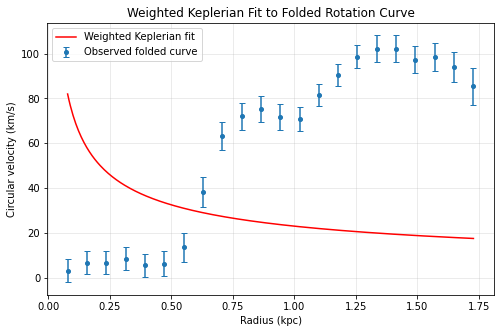

In [38]:
# --- Weighted Keplerian fit ---

G = 4.30091e-6  # kpc (km/s)^2 / Msun

def keplerian_v(r, M):
    return np.sqrt(G * M / r)

# Re-create fit_mask and v_err_fit as they were defined in the NFW fit block
# Assumes R_obs, v_obs, v_obs_err are defined from previous cells (rn1F0J1ii40S)
fit_mask = (
    np.isfinite(R_obs) &
    np.isfinite(v_obs) &
    np.isfinite(v_obs_err) &
    (R_obs > 0) &
    (v_obs > 0) &
    (v_obs_err > 0) &
    (v_obs_err < 100)
)

R_fit = R_obs[fit_mask]
v_fit = v_obs[fit_mask]
v_err_fit = v_obs_err[fit_mask]

M_fit = 1e10 #guess

popt_kep, pcov_kep = curve_fit(
    keplerian_v,
    R_fit,
    v_fit,
    sigma=v_err_fit,
    absolute_sigma=True,
    p0=[M_fit],
    bounds=([1e6], [1e13]),
    maxfev=10000
)

M_fit_weighted = popt_kep[0]
M_fit_weighted_err = np.sqrt(np.diag(pcov_kep))[0]

v_kep_fit = keplerian_v(R_fit, M_fit_weighted)

chi2_kep = np.sum(((v_fit - v_kep_fit) / v_err_fit)**2)
dof_kep = len(v_fit) - 1
chi2_red_kep = chi2_kep / dof_kep

print(f"Weighted Keplerian mass = {M_fit_weighted:.3e} \u00b1 {M_fit_weighted_err:.3e} Msun")
print(f"Keplerian chi-squared = {chi2_kep:.2f}")
print(f"Keplerian reduced chi-squared = {chi2_red_kep:.2f}")

# --- Plot the weighted fit ---

R_model = np.linspace(R_fit.min(), R_fit.max(), 300)
v_model = keplerian_v(R_model, M_fit_weighted)

plt.figure(figsize=(8,5))
plt.errorbar(
    R_obs[fit_mask],
    v_obs[fit_mask],
    yerr=v_obs_err[fit_mask],
    fmt='o',
    markersize=4,
    capsize=3,
    label="Observed folded curve"
)
plt.plot(R_model, v_model, color="red", label="Weighted Keplerian fit")

plt.xlabel("Radius (kpc)")
plt.ylabel("Circular velocity (km/s)")
plt.title("Weighted Keplerian Fit to Folded Rotation Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [39]:
# --- Chi-squared for Keplerian fit ---

# Evaluate Keplerian model at same fitted radii
v_kep_fit = keplerian_v(R_fit, M_fit)

# Chi-squared
chi2_kep = np.sum(((v_fit - v_kep_fit) / v_err_fit)**2)

# Degrees of freedom
# Keplerian fit has 1 fitted parameter: M_fit
dof_kep = len(v_fit) - 1

chi2_red_kep = chi2_kep / dof_kep

print(f"Keplerian chi-squared = {chi2_kep:.2f}")
print(f"Keplerian degrees of freedom = {dof_kep}")
print(f"Keplerian reduced chi-squared = {chi2_red_kep:.2f}")

Keplerian chi-squared = 57214.80
Keplerian degrees of freedom = 21
Keplerian reduced chi-squared = 2724.51


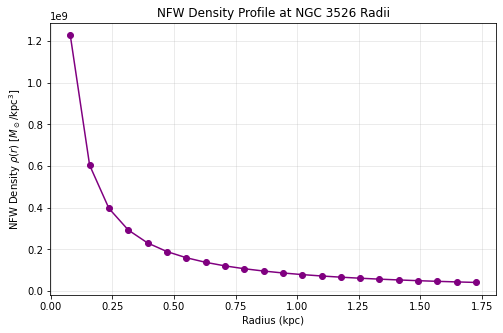

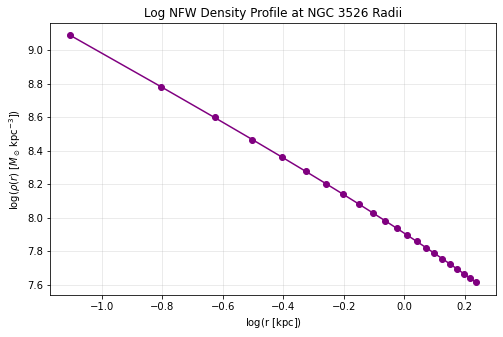

In [40]:
def nfw_density(r, rho_s, r_s):
    x = r / r_s
    return rho_s / (x * (1 + x)**2)

# NGC 3526 radii from folded rotation curve
R = np.array(R_unique, dtype=float)

mask = np.isfinite(R) & (R > 0)
R = R[mask]
R = np.sort(R)

# Example NFW parameters
rho_s = 1e7   # Msun / kpc^3
r_s = 9.8    # kpc

rho_nfw = nfw_density(R, rho_s, r_s)

plt.figure(figsize=(8,5))
plt.plot(R, rho_nfw, marker="o", color="purple")

plt.xlabel("Radius (kpc)")
plt.ylabel(r"NFW Density $\rho(r)$ [$M_\odot / \mathrm{kpc}^3$]")
plt.title("NFW Density Profile at NGC 3526 Radii")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    np.log10(R),
    np.log10(rho_nfw),
    marker="o",
    color="purple"
)

plt.xlabel(r"$\log (\mathrm{r\ [kpc]})$")
plt.ylabel(r"$\log (\rho(r)\ [M_\odot\,\mathrm{kpc}^{-3}])$")

plt.title("Log NFW Density Profile at NGC 3526 Radii")

plt.grid(alpha=0.3)
plt.show()

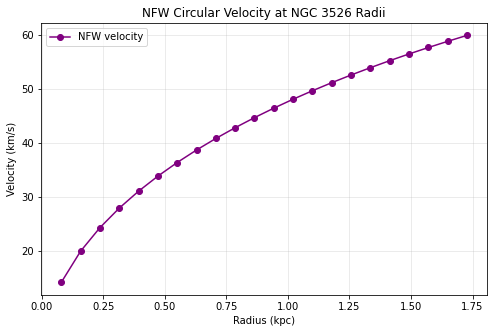

In [41]:
G = 4.30091e-6  # kpc (km/s)^2 / Msun

def nfw_mass(r, rho_s, r_s):
    x = r / r_s
    return 4 * np.pi * rho_s * r_s**3 * (
        np.log(1 + x) - x / (1 + x)
    )

def nfw_velocity(r, rho_s, r_s):
    M = nfw_mass(r, rho_s, r_s)
    return np.sqrt(G * M / r)

# NGC 3526 radii
R = np.array(R_unique, dtype=float)
R = R[np.isfinite(R) & (R > 0)]
R = np.sort(R)

# Same NFW parameters as your density profile
rho_s = 1e7 # Msun / kpc^3
r_s = 9.6 # kpc

v_nfw = nfw_velocity(R, rho_s, r_s)

plt.figure(figsize=(8,5))
plt.plot(R, v_nfw, marker="o", color="purple", label="NFW velocity")

plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("NFW Circular Velocity at NGC 3526 Radii")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Using 22 data points for fit
Best-fit rho_s = 3.738e+06 ± 1.392e+07 Msun/kpc^3
Best-fit r_s   = 50.000 ± 180.871 kpc


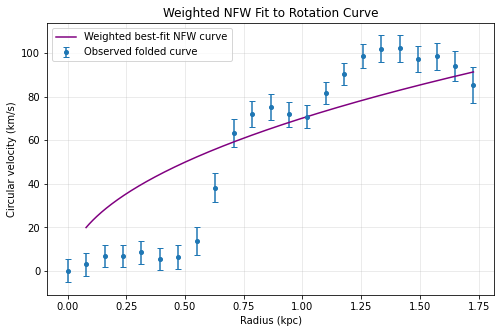

Chi-squared = 315.66
Degrees of freedom = 20
Reduced chi-squared = 15.78


In [42]:
# --- Weighted NFW fit to folded rotation curve (single-cell version) ---

# Clean dataset
fit_mask = (
    np.isfinite(R_obs) &
    np.isfinite(v_obs) &
    np.isfinite(v_obs_err) &
    (R_obs > 0) &
    (v_obs > 0) &
    (v_obs_err > 0) &
    (v_obs_err < 100)
)

R_fit = R_obs[fit_mask]
v_fit = v_obs[fit_mask]
v_err_fit = v_obs_err[fit_mask]

print(f"Using {len(R_fit)} data points for fit")

# Initial guesses and bounds
p0 = [1e7, 10.0]          # rho_s, r_s
bounds = ([1e5, 1.0],
          [1e9, 50.0])

# Perform weighted fit
popt, pcov = curve_fit(
    nfw_velocity,
    R_fit,
    v_fit,
    sigma=v_err_fit,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

rho_s_fit, r_s_fit = popt
rho_s_err, r_s_err = np.sqrt(np.diag(pcov))

print(f"Best-fit rho_s = {rho_s_fit:.3e} ± {rho_s_err:.3e} Msun/kpc^3")
print(f"Best-fit r_s   = {r_s_fit:.3f} ± {r_s_err:.3f} kpc")

# Smooth curve for plotting
R_smooth = np.linspace(np.min(R_obs[R_obs > 0]), np.max(R_obs), 500)
v_nfw_smooth = nfw_velocity(R_smooth, rho_s_fit, r_s_fit)

# Plot fit
plt.figure(figsize=(8,5))

plt.errorbar(
    R_obs,
    v_obs,
    yerr=v_obs_err,
    fmt="o",
    markersize=4,
    capsize=3,
    label="Observed folded curve"
)

plt.plot(
    R_smooth,
    v_nfw_smooth,
    color="purple",
    label="Weighted best-fit NFW curve"
)

plt.xlabel("Radius (kpc)")
plt.ylabel("Circular velocity (km/s)")
plt.title("Weighted NFW Fit to Rotation Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Compute reduced chi-squared
v_model_fit = nfw_velocity(R_fit, rho_s_fit, r_s_fit)

chi2 = np.sum(((v_fit - v_model_fit) / v_err_fit)**2)
dof = len(v_fit) - 2
chi2_red = chi2 / dof

print(f"Chi-squared = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-squared = {chi2_red:.2f}")

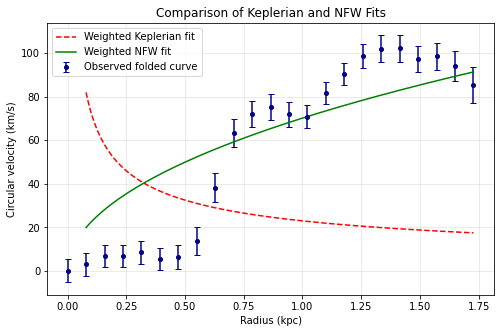

Reduced chi-squared (NFW)      = 15.78
Reduced chi-squared (Keplerian)= 109.30


In [43]:
# --- Compare weighted Keplerian and weighted NFW fits ---

# Smooth radius grid
R_smooth = np.linspace(np.min(R_obs[R_obs > 0]), np.max(R_obs), 500)

# Model curves
v_kep_smooth = keplerian_v(R_smooth, M_fit_weighted)
v_nfw_smooth = nfw_velocity(R_smooth, rho_s_fit, r_s_fit)

plt.figure(figsize=(8,5))

# Observed rotation curve
plt.errorbar(
    R_obs,
    v_obs,
    yerr=v_obs_err,
    fmt="o",
    markersize=4,
    capsize=3,
    color="darkblue",
    label="Observed folded curve"
)

# Keplerian model
plt.plot(
    R_smooth,
    v_kep_smooth,
    linestyle="--",
    color="red",
    label="Weighted Keplerian fit"
)

# NFW model
plt.plot(
    R_smooth,
    v_nfw_smooth,
    color="green",
    label="Weighted NFW fit"
)

plt.xlabel("Radius (kpc)")
plt.ylabel("Circular velocity (km/s)")
plt.title("Comparison of Keplerian and NFW Fits")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# --- Print reduced chi-squared values for comparison ---

# NFW reduced chi-squared (already computed earlier, but recompute safely here)
v_nfw_fit_vals = nfw_velocity(R_fit, rho_s_fit, r_s_fit)
chi2_nfw = np.sum(((v_fit - v_nfw_fit_vals) / v_err_fit)**2)
chi2_red_nfw = chi2_nfw / (len(v_fit) - 2)

# Keplerian reduced chi-squared
v_kep_fit_vals = keplerian_v(R_fit, M_fit_weighted)
chi2_kep = np.sum(((v_fit - v_kep_fit_vals) / v_err_fit)**2)
chi2_red_kep = chi2_kep / (len(v_fit) - 1)

print(f"Reduced chi-squared (NFW)      = {chi2_red_nfw:.2f}")
print(f"Reduced chi-squared (Keplerian)= {chi2_red_kep:.2f}")

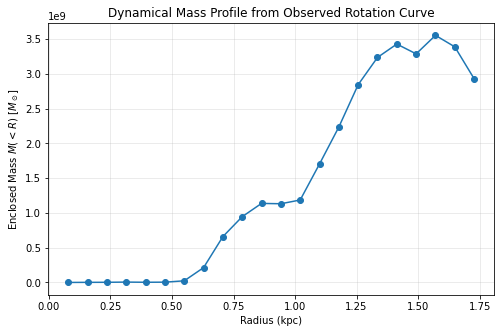

In [44]:
# Gravitational constant in useful astronomy units:
# kpc (km/s)^2 / Msun
G = 4.30091e-6

# Use the final folded rotation curve
R_mass = np.array(R_obs, dtype=float)   # kpc
v_mass = np.array(v_obs, dtype=float)   # km/s

# Clean the data
mask = (
    np.isfinite(R_mass) &
    np.isfinite(v_mass) &
    (R_mass > 0) &
    (v_mass > 0)
)

R_mass = R_mass[mask]
v_mass = v_mass[mask]

# Sort by radius
idx = np.argsort(R_mass)
R_mass = R_mass[idx]
v_mass = v_mass[idx]

# Dynamical enclosed mass:
# M(<R) = v^2 R / G
M_enclosed = (v_mass**2 * R_mass) / G

plt.figure(figsize=(8,5))
plt.plot(R_mass, M_enclosed, marker="o")

plt.xlabel("Radius (kpc)")
plt.ylabel(r"Enclosed Mass $M(<R)$ [$M_\odot$]")
plt.title("Dynamical Mass Profile from Observed Rotation Curve")
plt.grid(alpha=0.3)
plt.show()

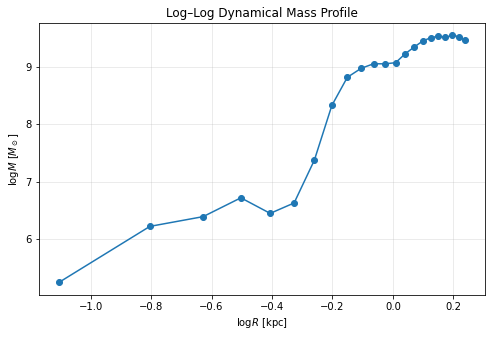

In [45]:
# --- Explicit log10(R) vs log10(M) dynamical mass profile ---

logR = np.log10(R_mass)
logM = np.log10(M_enclosed)

plt.figure(figsize=(8,5))

plt.plot(logR, logM, 'o-')

plt.xlabel(r"$\log R$ [kpc]")
plt.ylabel(r"$\log M$ [$M_\odot$]")
plt.title("Log–Log Dynamical Mass Profile")

plt.grid(alpha=0.3)

plt.show()

In [48]:
# --- Numerically integrate NFW density profile to get enclosed mass ---

def enclosed_mass_numeric(R, rho_s, r_s):

    integrand = lambda r: (
        4 * np.pi *
        nfw_density(r, rho_s, r_s) *
        r**2
    )

    mass, err = quad(integrand, 0, R)

    return mass

# Outer-most observed radius
R_max = R_mass[-1]

# Numerically integrated NFW mass
M_nfw_numeric = enclosed_mass_numeric(
    R_max,
    rho_s_fit,
    r_s_fit
)

print(f"NFW mass from direct numerical integration:")
print(f"M(<{R_max:.2f} kpc) = {M_nfw_numeric:.3e} Msun")


# Direct dynamical mass from observed rotation curve
M_dyn_total = M_enclosed[-1]
print(f"\nDirect dynamical mass from mass profile:")
print(f"M(<{R_max:.2f} kpc) = {M_dyn_total:.3e} Msun")

percentage_difference = ((M_nfw_numeric - M_dyn_total) / M_dyn_total) * 100
print(f"\nPercentage difference between NFW and dynamical mass: {percentage_difference:.2f}%")

NFW mass from direct numerical integration:
M(<1.73 kpc) = 3.351e+09 Msun

Direct dynamical mass from mass profile:
M(<1.73 kpc) = 2.928e+09 Msun

Percentage difference between NFW and dynamical mass: 14.42%


In [49]:
# --- Distance from Hubble's Law using systemic Hα wavelength ---

# Constants
H0 = 70  # km/s/Mpc

# Systemic velocity from fitted Hα centroid
v_sys = c_kms * (lambda_sys - lambda_rest) / lambda_rest

# Propagate wavelength uncertainty into velocity uncertainty
v_sys_err = c_kms * lambda_sys_err / lambda_rest

# Distance via Hubble's Law
D_Mpc = v_sys / H0
D_err = v_sys_err / H0

print(f"Systemic velocity: {v_sys:.1f} ± {v_sys_err:.1f} km/s")
print(f"Distance (Hubble's Law): {D_Mpc:.2f} ± {D_err:.2f} Mpc")

Systemic velocity: 1397.8 ± 5.3 km/s
Distance (Hubble's Law): 19.97 ± 0.08 Mpc


In [50]:
# --- Estimate stellar mass from B-band magnitude ---

# Inputs
m_B = 13.7          # apparent B-band magnitude
D_Mpc = 27          # distance in Mpc
M_B_sun = 5.48      # Sun's absolute magnitude in B band

# Assumed stellar mass-to-light ratio
ML_B = 2.0
ML_B_err = 1.0

# Distance modulus
M_B = m_B - 5 * np.log10(D_Mpc * 1e6 / 10)

# B-band luminosity in solar units
L_B = 10**(-0.4 * (M_B - M_B_sun))

# Stellar mass estimate
M_star = ML_B * L_B
M_star_err = ML_B_err * L_B

print(f"Absolute B magnitude: M_B = {M_B:.2f}")
print(f"B-band luminosity: L_B = {L_B:.3e} Lsun")

print("\nEstimated stellar mass:")
print(f"M_star = ({M_star:.3e} ± {M_star_err:.3e}) Msun")

print("\nRange from M/L uncertainty:")
print(f"Lower estimate (M/L = 1): {(1.0 * L_B):.3e} Msun")
print(f"Central estimate (M/L = 2): {(2.0 * L_B):.3e} Msun")
print(f"Upper estimate (M/L = 3): {(3.0 * L_B):.3e} Msun")

Absolute B magnitude: M_B = -18.46
B-band luminosity: L_B = 3.756e+09 Lsun

Estimated stellar mass:
M_star = (7.512e+09 ± 3.756e+09) Msun

Range from M/L uncertainty:
Lower estimate (M/L = 1): 3.756e+09 Msun
Central estimate (M/L = 2): 7.512e+09 Msun
Upper estimate (M/L = 3): 1.127e+10 Msun
